In [1]:
from aoespy import *

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [3]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/IAU_exp/',file='state_3d_set1',var=1,start_date='20050501',nfiles=120,freq='D',nz=50, nf=6, ni=90, nj=90, ntile=13,expdir='../mit_output/'):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob(file+'*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        print(data.shape)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((nlat,nlon))

    new_grid_lon_centers, new_grid_lat_centers,\
    new_grid_lon_edges, new_grid_lat_edges,\
    theta_djf_alli[:,:] =\
    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [4]:
import numpy as np

# your delR list (meters), top to bottom
delR = np.array([
    10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.01,10.03,10.11,10.32,10.80,11.76,13.42,16.04,19.82,24.85,
    31.10,38.42,46.50,55.00,63.50,71.58,78.90,85.15,90.18,93.96,96.58,98.25,99.25,100.01,101.33,104.56,
    111.33,122.83,139.09,158.94,180.83,203.55,226.50,249.50,272.50,295.50,318.50,341.50,364.50,387.50,410.50,456.50
])

# Vertical faces (interfaces): start at 0 at the surface, increase downward (m),
# then switch sign (negative) to match MITgcm convention.
RF_pos = np.concatenate([[0.0], np.cumsum(delR)])          # shape (Nr+1,)
RF = -RF_pos                                               # 0, -10, -20, ..., -6134.5

# Vertical centers: midpoints between faces
RC = - (RF_pos[:-1] + RF_pos[1:]) / 2.0                    # shape (Nr,)

print("Nr =", delR.size, "Total depth (m) =", delR.sum())
print("Top faces (first 5):", RF[:5])
print("Centers (first 5):  ", RC[:5])

Nr = 49 Total depth (m) = 5701.0
Top faces (first 5): [ -0. -10. -20. -30. -40.]
Centers (first 5):   [ -5. -15. -25. -35. -45.]


In [5]:
input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
input_file = 'bathy_eccollc_90x50_min2pts.bin'
ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
drF=ecco_grid.drF

In [34]:
# hFacC=ecco_grid.hFacC
# w=hFacC*delR 
ME506_Theta, time=readmit('GEOSMIT_ME0511',nz=50,nfiles=3,var=1,freq='D',start_date='20050511')

RP506_Theta, time=readmit('GEOSMIT_RP0511',nz=50,nfiles=3,var=1,freq='D',start_date='20050511')


load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000252.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000252.data
load_binary

In [37]:
# ME506_Theta, time=readmit('GEOSMIT_ME0416',nz=50,nfiles=3,var=1,freq='D',start_date='20050416')
# ME506_Theta=ME506_Theta[1,0,:,:,:]-ME506_Theta[0,0,:,:,:]
# ME506_Theta=llc2grd(ME506_Theta)
# plt.contourf(ME506_Theta[0],cmap='coolwarm',levels=arange(-.5,.51,.05),extend='both')
# plt.colorbar()
#surf=xr.open_mfdataset("/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_surf/200504/GEOSMIT_ME0416.geosgcm_surf.2005041*").resample(time="D").mean()
#(surf.TS_FOUND[1,:,:]-surf.TS_FOUND[0,:,:]).plot(cmap='coolwarm',levels=arange(-.5,.51,.05))

In [38]:
# hFacC=ecco_grid.hFacC
# w=hFacC*delR 


ME506_Q, time=readmit('GEOSMIT_ME0511',nz=1,file='state_2d_set1',nfiles=3,var=4,freq='D',nf=11,start_date='20050511')

RP506_Q, time=readmit('GEOSMIT_RP0511',nz=1,file='state_2d_set1',nfiles=3,var=4,freq='D',nf=11,start_date='20050511')


load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000000252.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000252.data
load_binary_arra

In [39]:
HFacC=ecco_grid.hFacC
H = 10.0  # m

# Build interfaces (length 51) WITHOUT keeping any stray 'k' coord
rF = xr.concat(
    [
        xr.zeros_like(drF.isel(k=0)).rename({'k':'k_i'}).expand_dims({'k_i':[0]}),
        drF.rename({'k':'k_i'}).cumsum('k_i')
    ],
    dim='k_i'
)

# IMPORTANT: remove any leftover coord named 'k' to avoid rename conflict
if 'k' in rF.coords:
    rF = rF.reset_coords('k', drop=True)

z_top = rF.isel(k_i=slice(0, -1))
z_bot = rF.isel(k_i=slice(1,  None))
# drop stray 'k' coord if present
for da in (z_top, z_bot):
    if 'k' in da.coords:
        da = da.reset_coords('k', drop=True)
z_top = z_top.swap_dims({'k_i':'k'})
z_bot = z_bot.swap_dims({'k_i':'k'})

# Overlap with the 0–50 m slab
z_top_c = xr.ufuncs.maximum(z_top, 0.0)
z_bot_c = xr.ufuncs.minimum(z_bot, H)
dz_star = xr.ufuncs.maximum(0.0, z_bot_c - z_top_c)  # (k)

# Weights (broadcast over space): w has same dims as HFacC
w = dz_star * HFacC
h_eff = w.sum('k')  # effective local slab depth

/tmp/ipykernel_86272/1700249288.py:27: FutureWarning: xarray.ufuncs is deprecated. Instead, use numpy ufuncs directly.
  z_top_c = xr.ufuncs.maximum(z_top, 0.0)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/xarray/core/dataarray.py:3098: FutureWarning: xarray.ufuncs is deprecated. Instead, use numpy ufuncs directly.
  f(self.variable, other_variable)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/xarray/core/variable.py:2467: FutureWarning: xarray.ufuncs is deprecated. Instead, use numpy ufuncs directly.
  f(self_data, other_data) if not reflexive else f(other_data, self_data)
/tmp/ipykernel_86272/1700249288.py:28: FutureWarning: xarray.ufuncs is deprecated. Instead, use numpy ufuncs directly.
  z_bot_c = xr.ufuncs.minimum(z_bot, H)
/tmp/ipykernel_86272/1700249288.py:29: FutureWarning: xarray.ufuncs is deprecated. Instead, use numpy ufuncs directly.
  dz_star = xr.ufuncs.maximum(0.0, z_bot_c - z_top_c)  # (k)
/nobac

In [41]:
ME506_Theta = xr.DataArray(
    ME506_Theta,
    dims=("time","k","tile","j","i"),
    coords={
        "time": time,   # or your own time vector, same length as theta.shape[0]
        "k":     w["k"],
        "tile":  w["tile"],
        "j":     w["j"],
        "i":     w["i"],
    },
    name="THETA"
)

RP506_Theta = xr.DataArray(
    RP506_Theta,
    dims=("time","k","tile","j","i"),
    coords={
        "time": time,   # or your own time vector, same length as theta.shape[0]
        "k":     w["k"],
        "tile":  w["tile"],
        "j":     w["j"],
        "i":     w["i"],
    },
    name="THETA"
)

RP506_Q = xr.DataArray(
    squeeze(RP506_Q),
    dims=("time","tile","j","i"),
    coords={
        "time": time,   # or your own time vector, same length as theta.shape[0]
        "tile":  w["tile"],
        "j":     w["j"],
        "i":     w["i"],
    },
    name="Q"
)

ME506_Q = xr.DataArray(
    squeeze(ME506_Q),
    dims=("time","tile","j","i"),
    coords={
        "time": time,   # or your own time vector, same length as theta.shape[0]
        "tile":  w["tile"],
        "j":     w["j"],
        "i":     w["i"],
    },
    name="Q"
)

In [42]:
rho = 1025.0
cp  = 3985.0
H_fixed = 10.0            # fixed slab depth (m) for Tier-1 headline metric
sec_day = 86400.0

In [43]:
heff = w.sum("k")
ME506_Tml=(ME506_Theta * w).sum(axis=1)/heff
RP506_Tml=(RP506_Theta * w).sum(axis=1)/heff

In [44]:
import numpy as np

sec_day = 86400.0
rho, cp, H_fixed = 1025.0, 3985.0, 50.0  # constants

# Ensure alignment/order
ME506_Tml = ME506_Tml.transpose("time","tile","j","i").sortby("time")
ME506_Q   = ME506_Q.transpose("time","tile","j","i").sel(time=ME506_Tml.time)

# --- indices for the first interval ---
T0 = ME506_Tml.isel(time=0)
T1 = ME506_Tml.isel(time=1)
Q01_mean = ME506_Q.isel(time=slice(0,1)).mean("time")  # interval-mean forcing (best for budgets)

# Δt in days between first two daily stamps (robust to imperfect calendars)
dt_days = float((ME506_Tml.time.isel(time=1) - ME506_Tml.time.isel(time=0)) / np.timedelta64(1,"D"))

# 1) First-step tendency (K/day): forward difference Day2 - Day1 over Δt
ME506_dTdt_01 = ((T1 - T0) / dt_days).rename("ME506_dTdt_01")

# 2) Surface forcing for the same interval (K/day): interval-mean Q / (ρ c_p h)
ME506_Surf_01 = ((Q01_mean / (rho * cp * H_fixed)) * sec_day).rename("ME506_Surf_01")

# (Optional strict local conservation) if you have heff = w.sum("k"):
# ME506_Surf_01 = ((Q01_mean / (rho * cp * heff)) * sec_day).rename("ME506_Surf_01")

# 3) Residual for the first interval (K/day)
ME506_Residual_01 = (ME506_dTdt_01 - ME506_Surf_01).rename("ME506_Residual_01")


In [45]:
import numpy as np

sec_day = 86400.0
rho, cp, H_fixed = 1025.0, 3985.0, 50.0  # constants

# Ensure alignment/order
RP506_Tml = RP506_Tml.transpose("time","tile","j","i").sortby("time")
RP506_Q   = RP506_Q.transpose("time","tile","j","i").sel(time=RP506_Tml.time)

# --- indices for the first interval ---
T0 = RP506_Tml.isel(time=0)
T1 = RP506_Tml.isel(time=1)
Q01_mean = RP506_Q.isel(time=slice(0,1)).mean("time")  # interval-mean forcing (best for budgets)

# Δt in days between first two daily stamps (robust to imperfect calendars)
dt_days = float((RP506_Tml.time.isel(time=1) - RP506_Tml.time.isel(time=0)) / np.timedelta64(1,"D"))

# 1) First-step tendency (K/day): forward difference Day2 - Day1 over Δt
RP506_dTdt_01 = ((T1 - T0) / dt_days).rename("RP506_dTdt_01")

# 2) Surface forcing for the same interval (K/day): interval-mean Q / (ρ c_p h)
RP506_Surf_01 = ((Q01_mean / (rho * cp * H_fixed)) * sec_day).rename("RP506_Surf_01")

# (Optional strict local conservation) if you have heff = w.sum("k"):
# RP506_Surf_01 = ((Q01_mean / (rho * cp * heff)) * sec_day).rename("RP506_Surf_01")

# 3) Residual for the first interval (K/day)
RP506_Residual_01 = (RP506_dTdt_01 - RP506_Surf_01).rename("RP506_Residual_01")


In [46]:
RP506_dTdt_01,new_lon, new_lat=llc2grd(RP506_dTdt_01,nz=1)
ME506_dTdt_01,new_lon, new_lat=llc2grd(ME506_dTdt_01,nz=1)

In [47]:
RP506_Surf_01,new_lon, new_lat=llc2grd(RP506_Surf_01,nz=1)
ME506_Surf_01,new_lon, new_lat=llc2grd(ME506_Surf_01,nz=1)

In [48]:
RP506_Residual_01,new_lon, new_lat=llc2grd(RP506_Residual_01,nz=1)
ME506_Residual_01,new_lon, new_lat=llc2grd(ME506_Residual_01,nz=1)

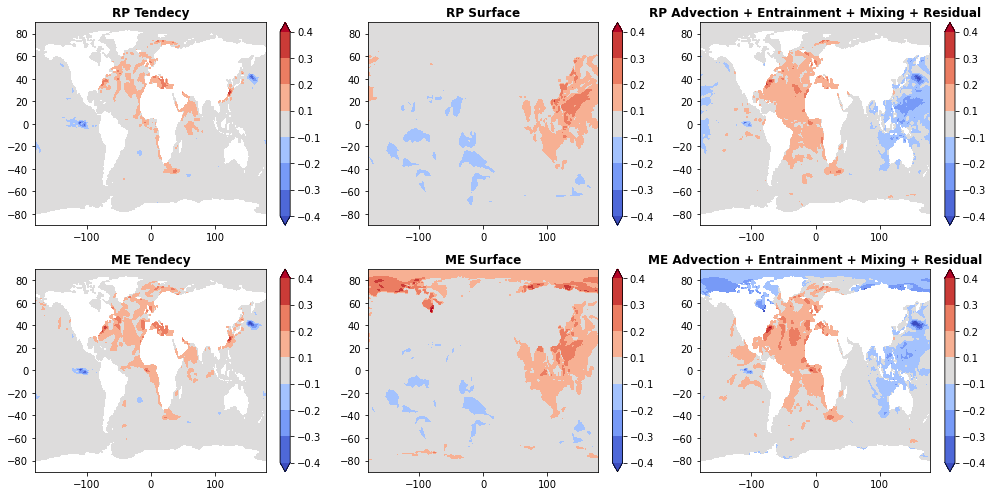

In [49]:
plt.figure(figsize=(14,7))
clf=arange(-.25,.251,.1)
clf=array([-.4,-.3,-.2,-.1,.1,.2,.3,.4])
plt.subplot(2,3,1)
plt.contourf(new_lon, new_lat,RP506_dTdt_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Tendecy',fontsize=12,fontweight='bold')

plt.subplot(2,3,2)
plt.contourf(new_lon, new_lat,RP506_Surf_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Surface',fontsize=12,fontweight='bold')

plt.subplot(2,3,3)
plt.contourf(new_lon, new_lat,RP506_Residual_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Advection + Entrainment + Mixing + Residual',fontsize=12,fontweight='bold')


plt.subplot(2,3,4)
plt.contourf(new_lon, new_lat,ME506_dTdt_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Tendecy',fontsize=12,fontweight='bold')
plt.subplot(2,3,5)
plt.contourf(new_lon, new_lat,ME506_Surf_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Surface',fontsize=12,fontweight='bold')

plt.subplot(2,3,6)
plt.contourf(new_lon, new_lat,ME506_Residual_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Advection + Entrainment + Mixing + Residual',fontsize=12,fontweight='bold')
plt.tight_layout()

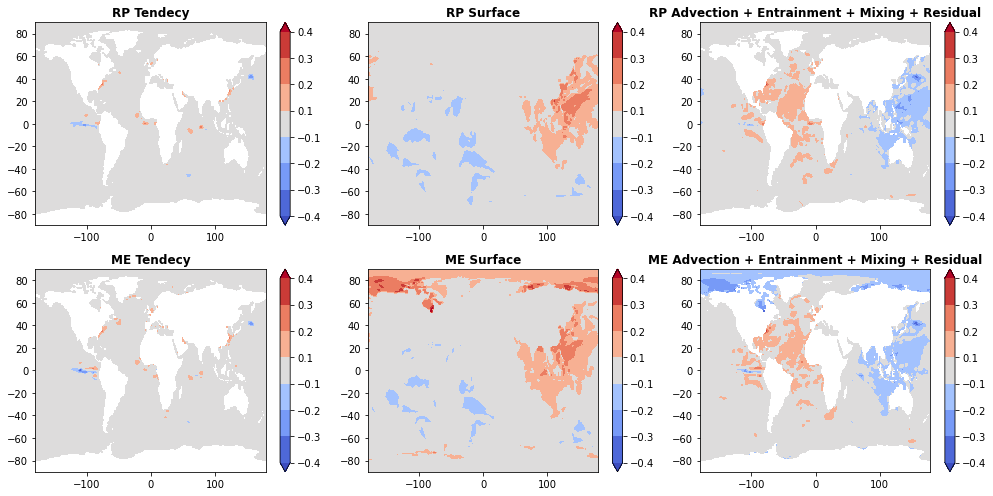

In [74]:
plt.figure(figsize=(14,7))
clf=arange(-.25,.251,.1)
clf=array([-.4,-.3,-.2,-.1,.1,.2,.3,.4])
plt.subplot(2,3,1)
plt.contourf(new_lon, new_lat,RP506_dTdt_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Tendecy',fontsize=12,fontweight='bold')

plt.subplot(2,3,2)
plt.contourf(new_lon, new_lat,RP506_Surf_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Surface',fontsize=12,fontweight='bold')

plt.subplot(2,3,3)
plt.contourf(new_lon, new_lat,RP506_Residual_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('RP Advection + Entrainment + Mixing + Residual',fontsize=12,fontweight='bold')


plt.subplot(2,3,4)
plt.contourf(new_lon, new_lat,ME506_dTdt_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Tendecy',fontsize=12,fontweight='bold')
plt.subplot(2,3,5)
plt.contourf(new_lon, new_lat,ME506_Surf_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Surface',fontsize=12,fontweight='bold')

plt.subplot(2,3,6)
plt.contourf(new_lon, new_lat,ME506_Residual_01,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME Advection + Entrainment + Mixing + Residual',fontsize=12,fontweight='bold')
plt.tight_layout()

Text(0.5, 1.0, 'ME - RP (Advection + Entrainment + Mixing + Residual) K/day')

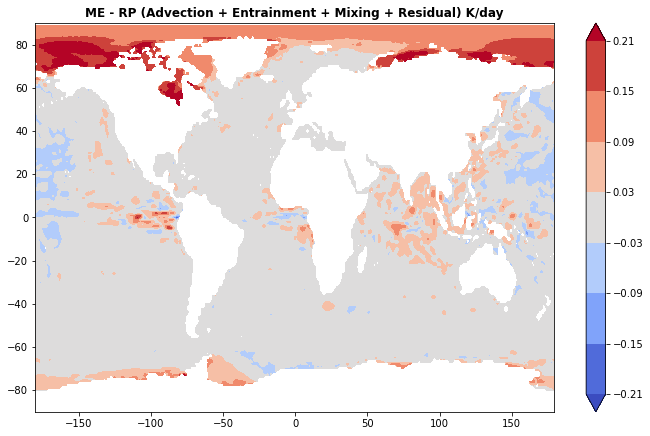

In [75]:
f()
clf=arange(-.21,.22,.06)
plt.contourf(new_lon, new_lat,abs(ME506_Residual_01)-abs(RP506_Residual_01),cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME - RP (Advection + Entrainment + Mixing + Residual) K/day',fontsize=12,fontweight='bold')

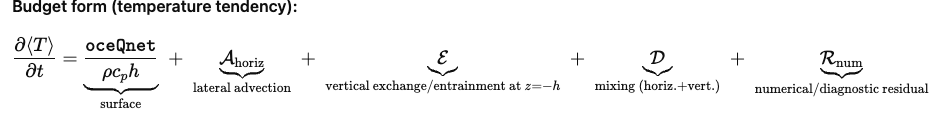

Text(0.5, 1.0, 'ME - RP (Advection + Entrainment + Mixing + Residual) K/day')

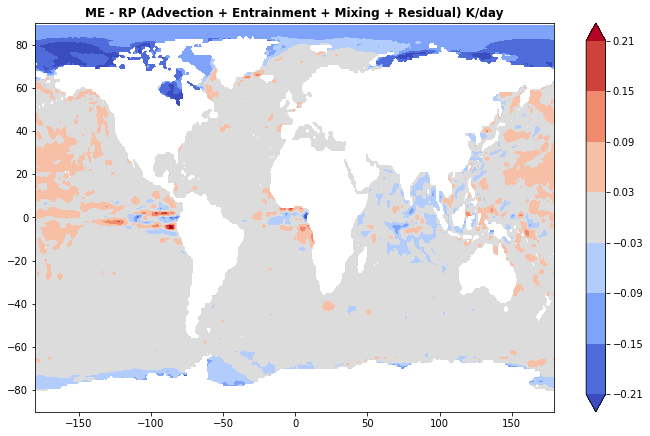

In [76]:
f()
clf=arange(-.21,.22,.06)
plt.contourf(new_lon, new_lat,(ME506_Residual_01)-(RP506_Residual_01),cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME - RP (Advection + Entrainment + Mixing + Residual) K/day',fontsize=12,fontweight='bold')

In [77]:
diff=(ME506_Residual_01)-(RP506_Residual_01)
savez("diff511.npz",diff=diff)

In [78]:
diff1=load("diff416.npz")["diff"]
diff2=load("diff421.npz")["diff"]
diff3=load("diff426.npz")["diff"]
diff4=load("diff511.npz")["diff"]

In [79]:
diff=(diff1+diff2+diff3+diff4)/4

Text(0.5, 1.0, 'ME - RP (Advection + Entrainment + Mixing + Residual) K/day')

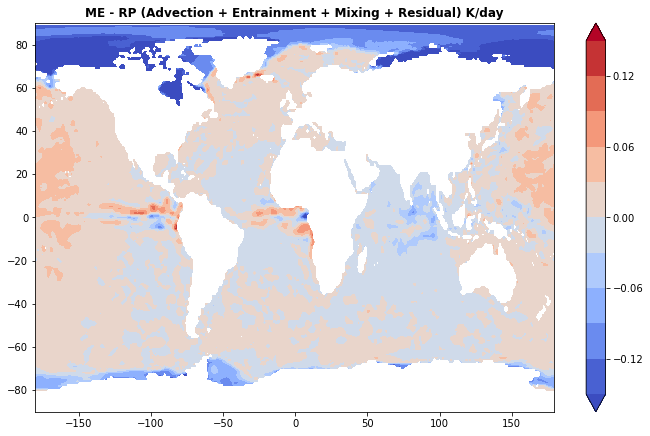

In [80]:
f()
clf=arange(-.15,.151,.03)
plt.contourf(new_lon, new_lat,diff,cmap='coolwarm',levels=clf,extend='both')
plt.colorbar()
plt.title('ME - RP (Advection + Entrainment + Mixing + Residual) K/day',fontsize=12,fontweight='bold')

In [81]:
diff = xr.Dataset(
    {
        "diff": (["lat", "lon"], diff)
    },
    coords={
        "lon": (["lon"], new_lon),
        "lat": (["lat"], new_lat)
    }
)

In [82]:
diff=diff["diff"]

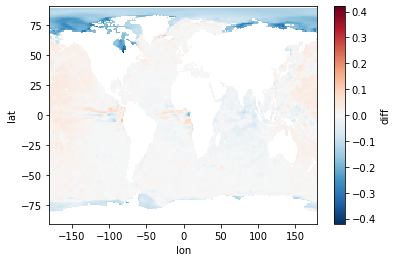

In [84]:
diff.plot()

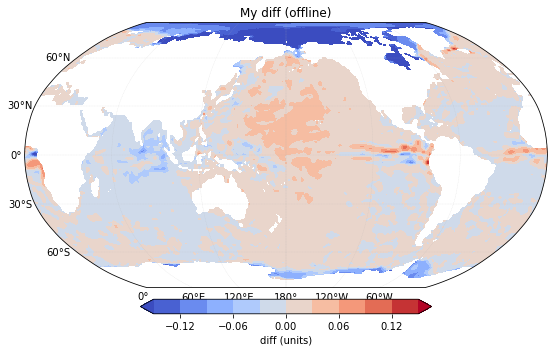

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point


def plot_diff_robinson_no_features(
    diff,
    title="Robinson Projection of diff",
    central_longitude=0,
    cmap="coolwarm",
    levels=None,          # e.g., np.linspace(-2, 2, 17); if provided uses contourf
    vmin=None, vmax=None, # used for pcolormesh if levels is None
    extend="neither",    # "neither", "min", "max", or "both" (contourf only)
    gridlines=True,
    colorbar=True,
    cbar_label=None,      # defaults to diff.units if present
    figsize=(10, 5),
):
    """
    Plot an xarray.DataArray `diff(lat, lon)` on a Robinson projection **without**
    any Cartopy features (no coastlines/land/borders), so it runs fully offline.

    Parameters
    ----------
    diff : xarray.DataArray
        2D array with dims (lat, lon); lon can be in [-180,180] or [0,360].
    title : str
        Plot title.
    central_longitude : float
        Central meridian for the Robinson projection (e.g., 0 or 180).
    cmap : str or Colormap
        Colormap for the field.
    levels : array-like or None
        If provided, draws filled contours (discrete bins). If None, uses pcolormesh.
    vmin, vmax : float or None
        Data limits for pcolormesh (ignored when `levels` is given).
    extend : str
        Colorbar extend for contourf: 'neither'|'min'|'max'|'both'.
    gridlines : bool
        Draw gridlines (safe offline).
    colorbar : bool
        Include a horizontal colorbar.
    cbar_label : str or None
        Colorbar label. Defaults to diff.units if available.
    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    (fig, ax)
    """
    # Ensure dims are (lat, lon)
    if tuple(diff.dims) != ("lat", "lon"):
        diff = diff.transpose("lat", "lon")

    # Ensure coordinates are monotonically increasing for stable pcolormesh/contourf
    if not np.all(np.diff(diff["lon"].values) > 0):
        diff = diff.sortby("lon")
    if not np.all(np.diff(diff["lat"].values) > 0):
        diff = diff.sortby("lat")

    lats = diff["lat"].values
    lons = diff["lon"].values

    # Add cyclic column at longitude edge to avoid map seam
    data_cyc, lons_cyc = add_cyclic_point(np.asarray(diff.values, dtype=float), coord=lons)

    # 2D lon/lat grids for pcolormesh/contourf in PlateCarree CRS
    lon2d, lat2d = np.meshgrid(lons_cyc, lats)

    # Figure & axes (no features added)
    fig = plt.figure(figsize=figsize)
    proj = ccrs.Robinson(central_longitude=central_longitude)
    ax = plt.axes(projection=proj)
    ax.set_global()

    # Draw data
    if levels is not None:
        mappable = ax.contourf(
            lon2d, lat2d, data_cyc,
            levels=levels,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            extend=extend,
        )
    else:
        mappable = ax.pcolormesh(
            lon2d, lat2d, data_cyc,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            shading="auto",
            vmin=vmin, vmax=vmax,
        )

    # Colorbar
    if colorbar:
        cb = plt.colorbar(mappable, ax=ax, orientation="horizontal", pad=0.04, fraction=0.05)
        label = cbar_label if cbar_label is not None else str(getattr(diff, "units", "diff (units)"))
        cb.set_label(label)

    ax.set_title(title)

    # Gridlines (does not require any external downloads)
    if gridlines:
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    plt.tight_layout()
    return fig, ax


# ----------------------
# Example usage (commented)
# ----------------------
# import xarray as xr
# ds = xr.open_dataset("diff_map.nc")
#diff = diff["diff"]
fig, ax = plot_diff_robinson_no_features(
    diff,
    title="My diff (offline)",
    central_longitude=180,
    # Discrete bins example:
    levels=np.arange(-.15, .151, .03), cmap="coolwarm", extend="both",
    # Or continuous shading example:
    #cmap="coolwarm", vmin=-3, vmax=3,
)
# fig.savefig("diff_robinson_offline.png", dpi=200, bbox_inches="tight")
